## SECTION 01
### What Is a Vector?

Forget everything complicated. A vector is just a list of numbers — an arrow that points somewhere. If you write v = [3, 2], that means "go 3 steps right and 2 steps up" from the origin.

But here's the key idea that 3Blue1Brown emphasizes: there are three ways to think about vectors, and you need all three depending on context:

### 🎓 PHYSICS VIEW
* An arrow with a direction and length. Can be moved around — only the direction and magnitude matter.

### 📐 MATH VIEW
* Anything that can be added together and scaled by a number, following certain rules (a "vector space").

### 💻 CS VIEW
* An ordered list of numbers. [3, 2] in 2D, [1, 0, -4, 7] in 4D. Each entry is a "feature."
  
### 🤖 ML VIEW
* A data point. Each image, sentence, or user is represented as a vector of numbers in some high-dimensional space.

In [4]:
# KEY INSIGHT
# For IOAI, the CS/math hybrid view dominates. 
# A vector is a column of numbers that lives in ℝⁿ (the set of all lists of n real numbers). 
# A 28×28 pixel grayscale image? That's a vector in ℝ⁷⁸⁴ — just flatten all 784 pixels into one long list.

In [5]:
# Notation you must know

# Vectors are written as column vectors by default in math:

# COLUMN VECTOR IN ℝ³
# v = ⎡ 3 ⎤
#     ⎢ 2 ⎥
#     ⎣-1 ⎦

# We write this compactly as v = [3, 2, -1]ᵀ where the ᵀ means transpose — flip the row into a column. 
# The number of entries is the dimension. This vector is in ℝ³ (three-dimensional real space).

In [34]:
import numpy as np

# Creating vectors
v = np.array([3, 2, -1])          # Shape: (3,) — 1D array
v_col = np.array([[3], [2], [-1]])  # Shape: (3,1) — actual column vector

print(f'v: {v} \n v_col: \n{v_col}')

# Easier way to make a column vector
v_col = v.reshape(-1, 1)             # Same thing: reshape to (3,1)

print(f'v_col: \n{v_col}')

print(v.shape)       # (3,)
print(v_col.shape)   # (3, 1)

v: [ 3  2 -1] 
 v_col: 
[[ 3]
 [ 2]
 [-1]]
v_col: 
[[ 3]
 [ 2]
 [-1]]
(3,)
(3, 1)


In [35]:
# COMMON BEGINNER TRAP
# In NumPy, np.array([3, 2, -1]) has shape (3,) — it's neither a row nor a column. 
# NumPy usually handles this fine, but in IOAI coding problems, shape mismatches cause silent bugs. 
# Always check .shape when debugging.

## SECTION 02
### Vector Operations

### __Addition: tip-to-tail__

To add two vectors, place the second one's tail at the first one's tip. The result goes from the origin to the second arrow's tip. Numerically: just add entry by entry.

In [37]:
# [3, 2] + [1, -1] = [3+1, 2+(-1)] = [4, 1]

### __Scalar multiplication: stretching__

Multiply every entry by the same number (the "scalar"). This stretches or flips the vector.

In [38]:
# 2 · [3, 2] = [6, 4]     (twice as long, same direction)

# -1 · [3, 2] = [-3, -2]    (same length, opposite direction)

✏️ Work this out on paper right now:

1. Given a = [2, 5] and b = [-1, 3]:

2. Compute a + b = [2+(-1), 5+3] = [1, 8]

3. Compute 3a = [6, 15]

4. Compute 2a - b = [2·2-(-1), 2·5-3] = [4+1, 10-3] = [5, 7]

Draw all of these on graph paper. See how 2a - b is a linear combination.

In [58]:
# 1
a = np.array([2, 5])
b = np.array([-1, 3])

# 2
print(a + b)

# 3 
print(3 * a)

# 4
print(2 * a - b)

# Length (magnitude / norm) of a vector
print(np.linalg.norm(a)) # sqrt(a1^2 + a2^2)

[1 8]
[ 6 15]
[5 7]
5.385164807134504


### __Dot product: how similar are two vectors?__

The dot product (inner product) of two vectors multiplies them entry-by-entry and sums up:

In [60]:
# a · b = a₁b₁ + a₂b₂ + ... + aₙbₙ

# [2, 5] · [-1, 3] = (2)(−1) + (5)(3) = −2 + 15 = 13


# The dot product has a geometric meaning:

# a · b = ‖a‖ · ‖b‖ · cos(θ)
# ||a|| is norm 

# Where θ is the angle between the vectors. This tells you:

# Positive dot product → vectors point in roughly the same direction (angle < 90°)
# Zero dot product → vectors are perpendicular (orthogonal) — this is huge in ML
# Negative dot product → vectors point in roughly opposite directions (angle > 90°)


# WHY IOAI CARES
# The dot product is the foundation of ALL of ML.
# Neural networks compute dot products between inputs and weights. 
# Cosine similarity (used in embeddings, search, recommendations) is just a normalized dot product.
# When you hear "attention mechanism in transformers" — it's dot products between query and key vectors.

In [65]:
# Dot product in NumPy
a = np.array([2, 5])
b = np.array([-1, 3])

print(np.dot(a,b))
print(a @ b)
print(np.sum(a * b))

# Checking orthogonality
u = np.array([1, 0])
v = np.array([0, 1])

print(u @ v) # 0 → perpendicular!

# Cosine similarity (used in embeddings)

def cosine_sim(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(cosine_sim(a, b))

13
13
13
0
0.7633862853691145


## SECTION 03
### Linear Combinations, Span & Independence

### __Linear combinations__

A linear combination is what you get when you scale some vectors and add them together:

In [66]:
# c₁v₁ + c₂v₂ + ... + cₖvₖ

In [68]:
# Where c₁, c₂, ... are scalars (any real numbers) and v₁, v₂, ... are vectors.

In [71]:
# Example: Let v₁ = [1, 0] and v₂ = [0, 1] (the standard basis vectors).
v1 = np.array([1, 0])
v2 = np.array([0, 1])

# Then 3v₁ + 2v₂ = 3[1,0] + 2[0,1] = [3, 0] + [0, 2] = [3, 2]
(3 * v1) + (2 * v2)

# In fact, any vector [a, b] = a·[1,0] + b·[0,1]. So every 2D vector is a linear combination of these two basis vectors!

array([3, 2])

### Span: what can you reach?

The span of a set of vectors is the set of ALL possible linear combinations of those vectors. Think: "what's the collection of every vector you can build by scaling and adding these vectors?"

In [72]:
# SPAN OF 1 VECTOR

# A line through the origin. You can only stretch/shrink along that one direction.

In [73]:
# SPAN OF 2 (INDEPENDENT) VECTORS

# A plane. Like how î and ĵ span all of 2D space.

In [74]:
# SPAN OF 2 PARALLEL VECTORS

# Still just a line! The second vector adds nothing new — it's "redundant."

In [75]:
# SPAN OF 3 VECTORS IN ℝ³

# All of 3D space (if independent), or a plane (if one is redundant), or a line (if two are).

### Linear independence: no redundancy

Vectors are linearly independent if none of them can be written as a linear combination of the others. Equivalently: the only way to get the zero vector from their linear combination is if ALL the scalars are zero.

In [76]:
# c₁v₁ + c₂v₂ + ... + cₖvₖ = 0  ⟹  c₁ = c₂ = ... = cₖ = 0

### Basis: the minimal spanning set

A basis for a vector space is a set of linearly independent vectors that spans the entire space. In ℝ², you need exactly 2 independent vectors. In ℝⁿ, you need exactly n.

The standard basis for ℝ³ is: e₁ = [1,0,0], e₂ = [0,1,0], e₃ = [0,0,1]. But there are infinitely many valid bases — any 3 independent vectors in ℝ³ work.

In [77]:
# IOAI CONNECTION — PCA

# PCA (Principal Component Analysis) finds a new basis for your data — 
# one where the first basis vector captures the most variance, 
# the second captures the next most, etc. 
# You then keep only the first k basis vectors, reducing dimensions from n to k. 
# This is Day 7 material, but it's built entirely on these concepts.

## SECTION 04
### What Is a Matrix?

A matrix is a rectangular grid of numbers. An m×n matrix has m rows and n columns:

In [79]:
# A = ⎡ 1   2   3 ⎤
#     ⎣ 4   5   6 ⎦

In [80]:
# But there's a much deeper way to think about this. 3Blue1Brown's key insight:

# THE BIG IDEA (3B1B VIDEO 3)
# A matrix IS a transformation. 
# Its columns tell you where the basis vectors land after the transformation. 
# When you multiply a matrix by a vector, you're applying that transformation to the vector.

## SECTION 05
### Matrices as Transformations (The Geometric View)

This is the single most important idea in 3Blue1Brown's series. A 2×2 matrix takes every point in 2D space and moves it to a new location. The matrix columns tell you where [1,0] and [0,1] end up.

(2, 5)
[[0 3 4 1 0]
 [0 0 2 2 0]]
(2, 5)
(2, 5)
(2, 2)


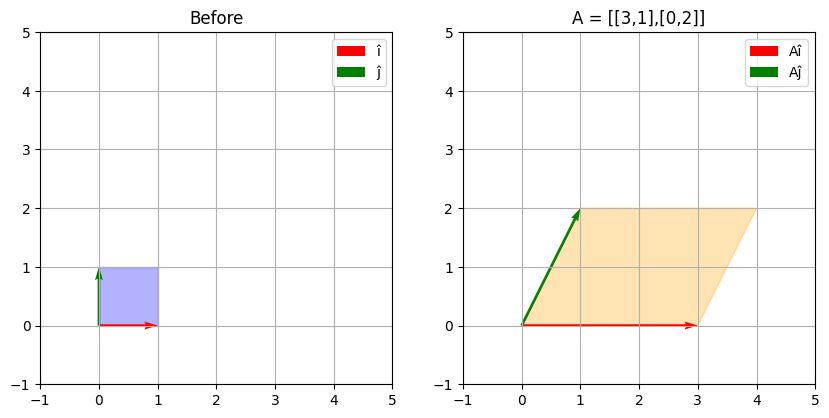

In [89]:
import matplotlib.pyplot as plt
import numpy as np

def plot_transformation(A, title="Transformation"):
    """Visualize how matrix A transforms the unit square."""
    # Unit square corners
    square = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]]).T
    print(square.shape)
    # Transform it
    transformed = A @ square
    print(transformed)
    print(square.shape)
    print(transformed.shape)
    print(A.shape)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    # Before
    ax1.fill(square[0], square[1], alpha=0.3, color='blue')
    ax1.quiver(0, 0, 1, 0, angles='xy', scale=1, scale_units='xy', color='red', label='î')
    ax1.quiver(0, 0, 0, 1, angles='xy', scale=1, scale_units='xy', color='green', label='ĵ')
    ax1.set_title("Before")
    ax1.set_xlim(-1, 5); ax1.set_ylim(-1, 5)
    ax1.set_aspect('equal'); ax1.grid(True); ax1.legend()
    
    # After
    ax2.fill(transformed[0], transformed[1], alpha=0.3, color='orange')
    ax2.quiver(0,0, A[0,0],A[1,0], angles='xy', scale=1, scale_units='xy', color='red', label='Aî')
    ax2.quiver(0,0, A[0,1],A[1,1], angles='xy', scale=1, scale_units='xy', color='green', label='Aĵ')
    ax2.set_title(title)
    ax2.set_xlim(-1, 5); ax2.set_ylim(-1, 5)
    ax2.set_aspect('equal'); ax2.grid(True); ax2.legend()
    plt.show()

# Try these!
A = np.array([[3, 1], [0, 2]])
plot_transformation(A, "A = [[3,1],[0,2]]")

## SECTION 06
### Determinants — The Area Scaling Factor

The determinant of a matrix tells you how much the transformation scales area (in 2D) or volume (in 3D).

In [68]:
import numpy as np

# Solving systems in NumPy
A = np.array([[1, 2], [3, 1]])
b = np.array([5, 10])
x = np.linalg.solve(A, b)
print(x)                      # [3. 1.]
print(np.allclose(A @ x, b))  # True

# YOUR TASK: Implement Gaussian elimination from scratch
def gauss_solve(A, b):
    """Solve Ax = b using Gaussian elimination with back-substitution."""
    n = len(b)
    # Build augmented matrix [A | b]
    aug = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
    
    # Forward elimination
    for col in range(n):
        # Find pivot (row with largest absolute value in this column)
        max_row = col + np.argmax(np.abs(aug[col:, col]))
        aug[[col, max_row]] = aug[[max_row, col]]  # swap rows
        
        # Eliminate below
        for row in range(col + 1, n):
            factor = aug[row, col] / aug[col, col]
            aug[row] -= factor * aug[col]
    
    # Back-substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (aug[i, -1] - aug[i, :-1] @ x) / aug[i, i]
    return x

# Test
x = gauss_solve(A, b)
print(x)  # [3. 1.]

[3. 1.]
True
[3. 1.]


In [14]:
print(A.shape)
print(A)
print(b.reshape(-1,1))

aug = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
print(aug)

(2, 2)
[[1 2]
 [3 1]]
[[ 5]
 [10]]
[[ 1.  2.  5.]
 [ 3.  1. 10.]]


In [19]:
import numpy as np
A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]])
b = np.array([8, -11, -3])

x = np.linalg.solve(A, b)

print(np.allclose(A @ x, b))

True


In [20]:
def gauss_sove(A, b):
    n = len(b)

    aug = np.hstack([A.astype(float), b.reshape(-1,1).astype(float)])
    

In [22]:
A = np.array([[1, 1, 1],
                [2, 3, 1],
                [1, 1, 2]])
b = np.array([6, 14, 9])

aug_hand = np.array([[1, 1, 1, 6],
                [2, 3, 1, 14],
                [1, 1, 2, 9]])

aug = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
aug

array([[ 1.,  1.,  1.,  6.],
       [ 2.,  3.,  1., 14.],
       [ 1.,  1.,  2.,  9.]])

In [43]:
n = len(b)

for i in range(1, 2):
    print(i)

1


In [70]:

def gauss_solve(A,b):
    n = len(b)

    aug = np.hstack([A.astype(float), b.reshape(-1,1).astype(float)])
    
    for col in range(n):
        max_row = col + np.argmax(np.abs(aug[col:, col]))
        aug[[col, max_row]] = aug[[max_row, col]]

        for row in range(col+1, n):
            factor = aug[row, col] / aug[col, col]
            aug[row] -= factor * aug[col]

    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (aug[i, -1] - aug[i, :-1] @ x) / aug[i, i]
    return x
    
A = np.array([[2, 1, -1],
                [-3, -1, 2],
                [-2, 1, 2]])
b = np.array([8, -11, -3])
x = gauss_solve(A, b)
print(x)

[ 2.  3. -1.]


In [63]:
A = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])

print(A[[0, 1]])
# A[[0, 1]] = A[[1, 0]]
# print(A[[0, 1]])
print(len(A))

[[1 2 3]
 [4 5 6]]
3


In [49]:
x = np.zeros(3)
x

array([0., 0., 0.])

In [61]:
n=2
for i in range(n - 1, -1, -1):
    print(i)

1
0
